In [53]:
import pandas as pd
import numpy as np

In [54]:
# Cargar bases
df_empleo = pd.read_csv("empleo_prov_trimestre_tratada.csv")
df_eph    = pd.read_csv("eph_canasta_adultos_equiv.csv")


C:\Users\Fede\AppData\Local\Temp\ipykernel_22192\606620659.py:3: DtypeWarning: Columns (102,105) have mixed types. Specify dtype option on import or set low_memory=False.
  df_eph    = pd.read_csv("eph_canasta_adultos_equiv.csv")


In [55]:
# Ver qué columnas tienen algo de "pob" en el nombre
[p for p in df_eph.columns if "po" in p.lower()]


['COMPONENTE', 'PONDERA', 'PONDIIO', 'PONDII', 'PONDIH', 'pobre']

In [60]:
import pandas as pd
import numpy as np

# Cargar bases
df_empleo = pd.read_csv("empleo_prov_trimestre_tratada.csv")
df_eph    = pd.read_csv("eph_canasta_adultos_equiv.csv")

# Mapear aglomerado -> provincia
mapping_aglo_prov = {
    2:  "buenos_aires",                       # Gran La Plata
    3:  "buenos_aires",                       # Bahía Blanca - Cerri
    4:  "santa_fe",                           # Gran Rosario
    5:  "santa_fe",                           # Gran Santa Fe
    6:  "entre_rios",                         # Gran Paraná
    7:  "misiones",                           # Posadas
    8:  "chaco",                              # Gran Resistencia
    9:  "chubut",                             # Cdro. Rivadavia – Rada Tilly
    10: "mendoza",                            # Gran Mendoza
    12: "corrientes",
    13: "cordoba",
    14: "entre_rios",                         # Concordia
    15: "formosa",
    17: "neuquen",
    18: "santiago_del_estero",
    19: "jujuy",
    20: "santa_cruz",
    22: "catamarca",
    23: "salta",
    25: "la_rioja",
    26: "san_luis",
    27: "san_juan",
    29: "tucuman",
    30: "la_pampa",
    31: "tierra_del_fuego",
    32: "ciudad_autonoma_de_buenos_aires",
    33: "buenos_aires",                       # Partidos del GBA
    34: "buenos_aires",                       # Mar del Plata - Batán
    36: "cordoba",                            # Río Cuarto
    38: "buenos_aires",                       # San Nicolás – Villa Constitución
    91: "chubut",                             # Rawson – Trelew
    93: "rio_negro",                          # Viedma – Carmen de Patagones
}

df_eph["provincia_completa"] = df_eph["AGLOMERADO"].map(mapping_aglo_prov)
df_eph = df_eph[~df_eph["provincia_completa"].isna()].copy()

# Tiempo en EPH
df_eph["anio"] = df_eph["ANO4"]
df_eph["trimestre"] = df_eph["TRIMESTRE"]

# === Variables micro en EPH ===

# aglomerado
df_eph["aglomerado"] = df_eph["AGLOMERADO"]

# género
df_eph["gen"] = df_eph["CH04"]
df_eph["mujer"] = (df_eph["CH04"] == 2).astype(int)

# edad
df_eph["edad"] = df_eph["CH06"]

# estado civil
df_eph["e_civil"] = df_eph["CH07"]
df_eph["e_civil_casado"] = (df_eph["CH07"] == 2).astype(int)
df_eph["e_civil_soltero"] = (df_eph["CH07"] == 1).astype(int)

# horas ocupación principal
df_eph["ht_ocup"] = df_eph["PP3E_TOT"]

# nivel educativo
df_eph["nivel_ed"] = df_eph["NIVEL_ED"]
df_eph["secundario_o_mas"] = np.where(df_eph["NIVEL_ED"].between(4, 8), 1, 0)

# condición de actividad
df_eph["cond_act"] = df_eph["ESTADO"]
df_eph["ocupado"] = (df_eph["ESTADO"] == 1).astype(int)
df_eph["desocupado"] = (df_eph["ESTADO"] == 2).astype(int)
df_eph["activo"] = df_eph["ESTADO"].isin([1, 2]).astype(int)

# parentesco con jefe
df_eph["cond_parent"] = df_eph["CH03"]
df_eph["es_jefe"] = (df_eph["CH03"] == 1).astype(int)
df_eph["es_hijo"] = (df_eph["CH03"] == 3).astype(int)

# alfabetismo
df_eph["alfabet"] = (df_eph["CH08"] == 1).astype(int)

# categoría ocupacional
df_eph["cat_ocup"] = df_eph["CAT_OCUP"]

# ingreso per cápita familiar
df_eph["percap_fam"] = df_eph["IPCF"]

# tamaño de aglomerado (> 500k hab.)
df_eph["tama_aglomerado"] = (df_eph["MAS_500"] == "S").astype(int)

# >>> cond_pobre ya existe en df_eph; nos aseguramos que sea numérica 0/1
df_eph["pobre"] = df_eph["pobre"].astype(float)

# === Collapse EPH a provincia-anio-trimestre ===

group_cols = ["provincia_completa", "anio", "trimestre"]

def wmean(x, w):
    x = x.astype(float)
    return np.average(x, weights=w) if w.sum() > 0 else np.nan

def agg_func(g):
    res = {}
    res["edad_prom"] = wmean(g["edad"], g["PONDERA"])
    res["prop_mujer"] = wmean(g["mujer"], g["PONDERA"])
    res["ipcf_prom"] = wmean(g["percap_fam"], g["PONDERA"])
    res["tasa_actividad"] = wmean(g["activo"], g["PONDERA"])
    res["tasa_empleo"] = wmean(g["ocupado"], g["PONDERA"])
    res["tasa_desocupacion"] = wmean(g["desocupado"], g["PONDERA"])
    res["prop_secundario_o_mas"] = wmean(g["secundario_o_mas"], g["PONDERA"])
    res["prop_alfabetos"] = wmean(g["alfabet"], g["PONDERA"])
    res["prop_jefes"] = wmean(g["es_jefe"], g["PONDERA"])
    res["prop_hijos"] = wmean(g["es_hijo"], g["PONDERA"])
    if g["ocupado"].sum() > 0:
        res["horas_prom_ocup"] = wmean(
            g.loc[g["ocupado"] == 1, "ht_ocup"],
            g.loc[g["ocupado"] == 1, "PONDERA"]
        )
    else:
        res["horas_prom_ocup"] = np.nan
    res["prop_aglo_mas_500k"] = wmean(g["tama_aglomerado"], g["PONDERA"])
    # >>> nueva variable agregada: proporción de pobres
    res["prop_pobres"] = wmean(g["pobre"], g["PONDERA"])
    res["n_personas"] = g["PONDERA"].sum()
    return pd.Series(res)

agg = (
    df_eph
    .groupby(group_cols)
    .apply(agg_func)
    .reset_index()
)

# === Preparar base de empleo / tratamiento ===

df_empleo = df_empleo.rename(columns={
    "empleo_prom_trimestre": "empleo_prom",
    "salario_prom_trimestre": "salario_prom"
})
df_empleo["ln_empleo_prom"] = np.log(df_empleo["empleo_prom"])

# === Merge final para modelo ===

df_modelo = df_empleo.merge(
    agg,
    on=["provincia_completa", "anio", "trimestre"],
    how="inner"
)

# df_modelo ahora incluye 'prop_pobres' como predictor agregado


C:\Users\Fede\AppData\Local\Temp\ipykernel_22192\2111718318.py:6: DtypeWarning: Columns (102,105) have mixed types. Specify dtype option on import or set low_memory=False.
  df_eph    = pd.read_csv("eph_canasta_adultos_equiv.csv")


In [61]:
df_modelo.describe()

,anio,trimestre,empleo_prom,salario_prom,provincia_tratada,ln_empleo_prom,edad_prom,prop_mujer,ipcf_prom,tasa_actividad,tasa_empleo,tasa_desocupacion,prop_secundario_o_mas,prop_alfabetos,prop_jefes,prop_hijos,horas_prom_ocup,prop_aglo_mas_500k,prop_pobres,n_personas
count,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,2.400000e+02
mean,2017.800000,2.300000,2326.158428,28027.810645,0.825000,7.318513,33.901835,0.519385,8135.997886,0.439116,0.410367,0.028750,0.536134,0.641812,0.320496,0.385878,36.414091,0.286158,0.476614,7.711438e+05
std,0.749895,1.102299,3284.436294,11000.466911,0.380761,0.822274,2.090241,0.014203,3093.214528,0.042267,0.035845,0.014211,0.053743,0.086169,0.037766,0.029926,2.974638,0.447273,0.121721,2.004179e+06
min,2017.000000,1.000000,381.003623,13758.079254,0.000000,5.942809,29.666774,0.479051,2539.790820,0.318195,0.309072,0.004010,0.445147,0.449777,0.253711,0.270576,27.663403,0.000000,0.127164,3.162000e+04
25%,2017.000000,1.000000,826.917798,20315.285752,1.000000,6.717705,32.458246,0.511015,6017.756217,0.416757,0.391891,0.016823,0.500359,0.587857,0.290367,0.373861,34.526765,0.000000,0.406330,1.193282e+05
50%,2018.000000,2.000000,1369.935606,25352.073982,1.000000,7.222518,33.576511,0.518373,7679.032947,0.439351,0.408440,0.027220,0.529824,0.628983,0.316724,0.390451,36.294902,0.000000,0.475101,2.086205e+05
75%,2018.000000,3.000000,2417.730516,32804.907231,1.000000,7.790574,34.915628,0.528392,9426.285200,0.461518,0.427336,0.039997,0.561537,0.699341,0.343068,0.406130,38.253786,0.919825,0.562656,4.600120e+05
max,2019.000000,4.000000,17674.902622,83381.178194,1.000000,9.779901,41.891593,0.561768,22645.668151,0.576034,0.546923,0.071812,0.746723,0.873973,0.440651,0.439094,46.609989,1.000000,0.796090,1.422997e+07


In [62]:
df_eph["provincia_completa"].value_counts(dropna=False)


buenos_aires                       92886
cordoba                            24393
santa_fe                           22824
entre_rios                         19736
salta                              17483
chubut                             16195
tucuman                            15691
ciudad_autonoma_de_buenos_aires    15204
mendoza                            13717
san_juan                           12188
catamarca                          11455
jujuy                              11304
santiago_del_estero                10924
la_rioja                           10576
san_luis                            9941
formosa                             9851
chaco                               9536
corrientes                          9308
misiones                            8956
rio_negro                           8551
neuquen                             7941
tierra_del_fuego                    7775
la_pampa                            6868
santa_cruz                          6276
Name: provincia_

In [63]:
df_modelo.columns

Index(['provincia_completa', 'anio', 'trimestre', 'empleo_prom',
       'salario_prom', 'provincia_tratada', 'ln_empleo_prom', 'edad_prom',
       'prop_mujer', 'ipcf_prom', 'tasa_actividad', 'tasa_empleo',
       'tasa_desocupacion', 'prop_secundario_o_mas', 'prop_alfabetos',
       'prop_jefes', 'prop_hijos', 'horas_prom_ocup', 'prop_aglo_mas_500k',
       'prop_pobres', 'n_personas'],
      dtype='object')

In [64]:
# 1) Ver NAs por columna (todas las columnas de df_modelo)
df_modelo.isna().sum()


provincia_completa       0
anio                     0
trimestre                0
empleo_prom              0
salario_prom             0
provincia_tratada        0
ln_empleo_prom           0
edad_prom                0
prop_mujer               0
ipcf_prom                0
tasa_actividad           0
tasa_empleo              0
tasa_desocupacion        0
prop_secundario_o_mas    0
prop_alfabetos           0
prop_jefes               0
prop_hijos               0
horas_prom_ocup          0
prop_aglo_mas_500k       0
prop_pobres              0
n_personas               0
dtype: int64

# Modelos

In [67]:

# -----------------------------------
# 1. Elegir predictores 
# -----------------------------------

# Lista de variables explicativas que vamos a usar
cols_predictoras = [
    "empleo_prom",
    "salario_prom",
    "ln_empleo_prom",
    "edad_prom",
    "prop_mujer",
    "ipcf_prom",
    "tasa_actividad",
    "tasa_empleo",
    "tasa_desocupacion",
    "prop_secundario_o_mas",
    "prop_alfabetos",
    "prop_jefes",
    "prop_hijos",
    "horas_prom_ocup",
    "prop_aglo_mas_500k",
    "n_personas",
    "prop_pobres"
]

# Nos quedamos solo con las filas donde no haya NAs en Y ni en las X
df_modelo_ml = df_modelo.dropna(subset=cols_predictoras + ["provincia_tratada"]).copy()

X = df_modelo_ml[cols_predictoras]
y = df_modelo_ml["provincia_tratada"].astype(int)

print(X.shape, y.shape)


(240, 17) (240,)


In [68]:
import statsmodels.api as sm

# Agregamos constante
X_const = sm.add_constant(X)

logit_model = sm.Logit(y, X_const)
logit_res = logit_model.fit()

print(logit_res.summary())


Optimization terminated successfully.
         Current function value: 0.250338
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:      provincia_tratada   No. Observations:                  240
Model:                          Logit   Df Residuals:                      223
Method:                           MLE   Df Model:                           16
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.4602
Time:                        21:47:26   Log-Likelihood:                -60.081
converged:                       True   LL-Null:                       -111.29
Covariance Type:            nonrobust   LLR p-value:                 1.213e-14
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -15.7447     19.894     -0.791      0.429     -54.735      23


**1. Modelo Logit**

- El logit explica razonablemente bien qué provincias están tratadas (Pseudo R² ≈ 0,46).

- Variables asociadas a **mayor probabilidad de tratamiento**:
  - Una mayor **edad promedio** de la población (`edad_prom`) muestra un coeficiente positivo y es significativa al 10% (no al 5%), lo que sugiere que las provincias con población algo más envejecida tienden a estar tratadas, aunque la evidencia es moderada.

- Variables asociadas a **menor probabilidad de tratamiento**:
  - Un **mayor empleo promedio** (`empleo_prom`) tiene un coeficiente negativo y significativo: las provincias con mejores condiciones en el mercado de trabajo tienen menos probabilidad de recibir el programa.
  - Una mayor **proporción de alfabetos** (`prop_alfabetos`) también reduce fuertemente la probabilidad de tratamiento, lo que es consistente con una focalización hacia contextos con mayores rezagos educativos.

- El ingreso per cápita familiar (`ipcf_prom`) y el resto de las variables (tasas de actividad/empleo/desocupación, composición del hogar, etc.) no resultan estadísticamente significativas una vez controlamos por las demás. En particular, las tasas laborales presentan problemas de colinealidad (sus errores estándar aparecen como *NaN*), por lo que sus coeficientes no se interpretan directamente.


In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=123,
    stratify=y
)

# Modelo Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=123,
    class_weight="balanced"  # por si hay desbalance en provincia_tratada
)

rf.fit(X_train, y_train)

# Métricas básicas
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

# Importancia de variables
importances = pd.Series(rf.feature_importances_, index=cols_predictoras).sort_values(ascending=False)
print(importances)


              precision    recall  f1-score   support

           0       1.00      0.62      0.76        13
           1       0.92      1.00      0.96        59

    accuracy                           0.93        72
   macro avg       0.96      0.81      0.86        72
weighted avg       0.94      0.93      0.92        72

AUC: 0.9791395045632334
salario_prom             0.107112
prop_secundario_o_mas    0.098939
prop_alfabetos           0.094099
ln_empleo_prom           0.084986
empleo_prom              0.084099
ipcf_prom                0.081026
tasa_actividad           0.073372
tasa_empleo              0.065771
horas_prom_ocup          0.053754
prop_jefes               0.050684
edad_prom                0.043981
prop_pobres              0.038878
tasa_desocupacion        0.034418
prop_hijos               0.032613
n_personas               0.026748
prop_mujer               0.026388
prop_aglo_mas_500k       0.003132
dtype: float64


**2. Random Forest**

- El modelo de Random Forest logra un **muy buen desempeño predictivo**:
  - Accuracy ≈ **0,93** en el set de prueba.
  - AUC ≈ **0,98**, lo que indica una gran capacidad para separar provincias tratadas de no tratadas.

- El patrón de errores es consistente con la lógica de política pública:
  - Para las provincias **tratadas** (clase 1), el modelo tiene un recall ≈ **1,00**, es decir, prácticamente no deja fuera provincias que efectivamente reciben el programa (muy pocos falsos negativos).
  - En cambio, comete más errores clasificando como tratadas a algunas provincias no tratadas (falsos positivos), lo cual es menos costoso desde la perspectiva de no excluir beneficiarios potenciales.

- Las variables más importantes para clasificar provincias tratadas vs. no tratadas son:
  - Indicadores del **mercado de trabajo y de ingresos**: `salario_prom`, `empleo_prom` y `ln_empleo_prom`.
  - Indicadores **educativos**: `prop_secundario_o_mas` y `prop_alfabetos`.
  - Otros factores relevantes, aunque algo por detrás, son `ipcf_prom`, `tasa_actividad`, `tasa_empleo` y `horas_prom_ocup`. La proporción de pobres (`prop_pobres`) también tiene cierta importancia, pero menor.

- En conjunto, tanto el logit como el Random Forest apuntan a una misma lectura: el programa se concentra en provincias con **peores indicadores laborales y educativos**, lo que sugiere que la asignación del tratamiento está alineada con condiciones de vulnerabilidad, aunque los modelos sólo capturan **asociaciones** y no permiten inferir causalidad.





## Pregunta de Noelia: qué tipo de error preferimos?

“Desde la perspectiva de un organismo estatal que implementa un programa de apoyo territorial, consideramos más graves los errores de tipo II (falsos negativos), es decir, clasificar como ‘no tratada’ a una provincia que debería recibir el programa.

Este error implica dejar sin cobertura a una jurisdicción vulnerable, con costos sociales y políticos elevados. En cambio, los errores de tipo I (provincia clasificada como tratada cuando no le correspondería) implican un uso menos eficiente de los recursos, pero no generan exclusión de beneficiarios legítimos.

Por esa razón, al evaluar el desempeño del modelo damos mayor importancia a la sensibilidad (recall) de la clase tratada, incluso a costa de aceptar un mayor número de falsos positivos.”

# Visualizaciones

In [75]:
# Probabilidades predichas del LOGIT

# 1) Probabilidad de tratamiento para TODAS las observaciones
proba_logit_all = logit_res.predict(X_const)

# 2) Restricimos a las filas que quedaron en el set de test
y_pred_proba_logit = proba_logit_all.loc[X_test.index]

# (opcional) Predicción binaria para el test con umbral 0.5
y_pred_logit = (y_pred_proba_logit >= 0.5).astype(int)


In [77]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]


In [78]:
y_pred_proba_rf = y_prob


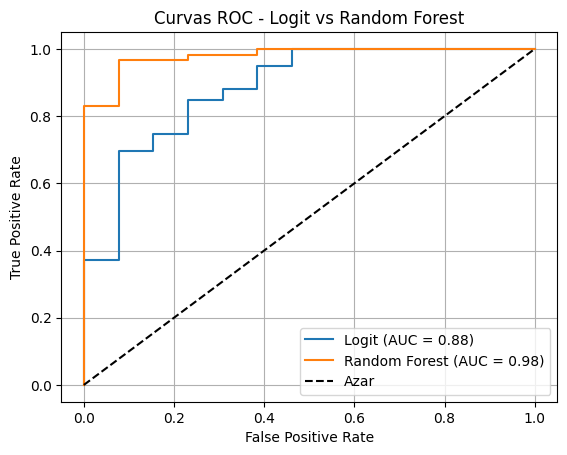

In [79]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# y_test: reales, y_pred_proba_logit: probs de clase 1 del logit
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_logit)
auc_log = auc(fpr_log, tpr_log)

# y_pred_proba_rf: probs de clase 1 del RF
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f'Logit (AUC = {auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC - Logit vs Random Forest')
plt.legend()
plt.grid(True)
plt.show()


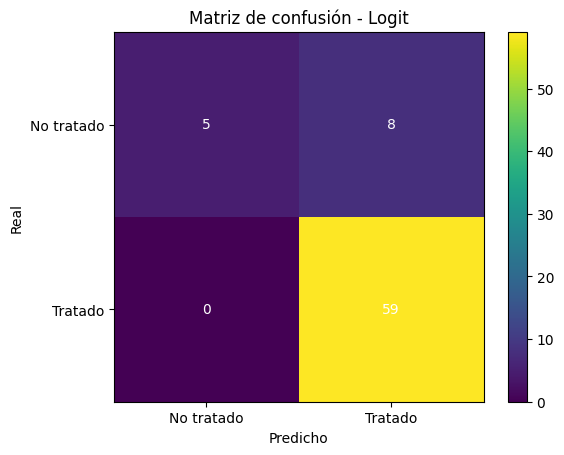

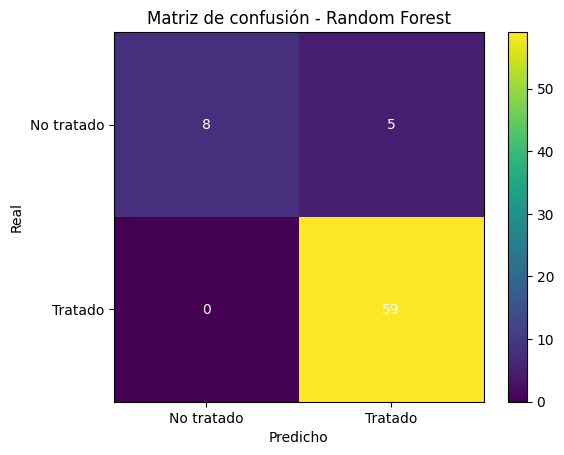

In [80]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(2)
    plt.xticks(ticks, ['No tratado', 'Tratado'])
    plt.yticks(ticks, ['No tratado', 'Tratado'])
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='white')
    plt.show()

# Predicciones binarias con umbral 0.5
y_pred_logit = (y_pred_proba_logit >= 0.5).astype(int)
y_pred_rf    = (y_pred_proba_rf >= 0.5).astype(int)

plot_conf_matrix(y_test, y_pred_logit, 'Matriz de confusión - Logit')
plot_conf_matrix(y_test, y_pred_rf, 'Matriz de confusión - Random Forest')


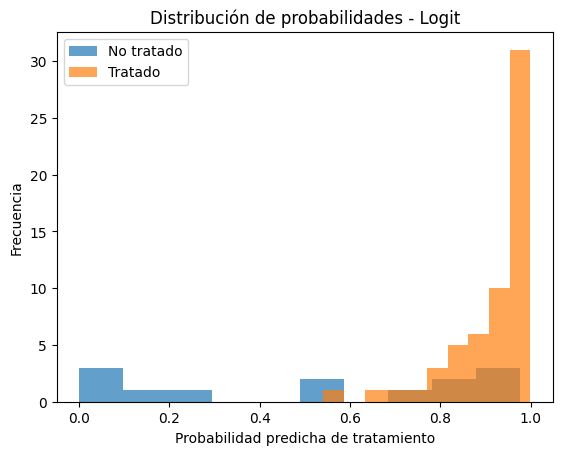

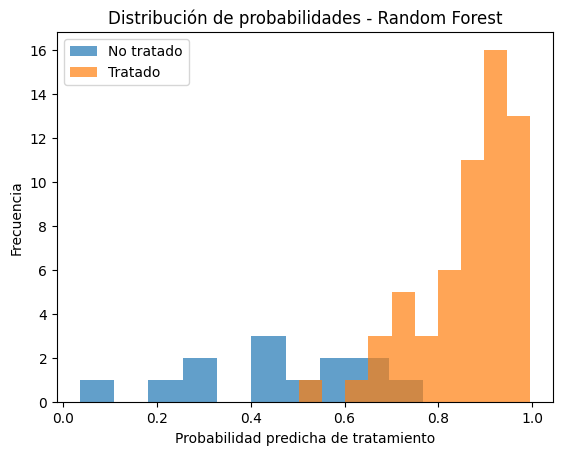

In [81]:
import matplotlib.pyplot as plt

def plot_proba_hist(y_true, y_proba, title):
    plt.figure()
    plt.hist(y_proba[y_true==0], bins=10, alpha=0.7, label='No tratado')
    plt.hist(y_proba[y_true==1], bins=10, alpha=0.7, label='Tratado')
    plt.xlabel('Probabilidad predicha de tratamiento')
    plt.ylabel('Frecuencia')
    plt.title(title)
    plt.legend()
    plt.show()

plot_proba_hist(y_test, y_pred_proba_logit, 'Distribución de probabilidades - Logit')
plot_proba_hist(y_test, y_pred_proba_rf, 'Distribución de probabilidades - Random Forest')


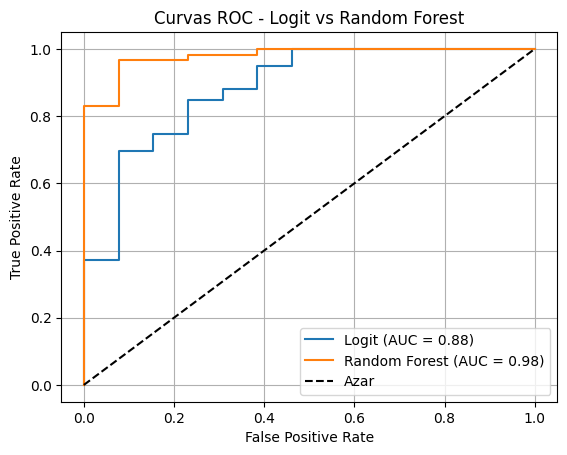

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Curva ROC LOGIT
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_logit)
auc_log = auc(fpr_log, tpr_log)

# Curva ROC Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob)  #
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f'Logit (AUC = {auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC - Logit vs Random Forest')
plt.legend()
plt.grid(True)
plt.show()


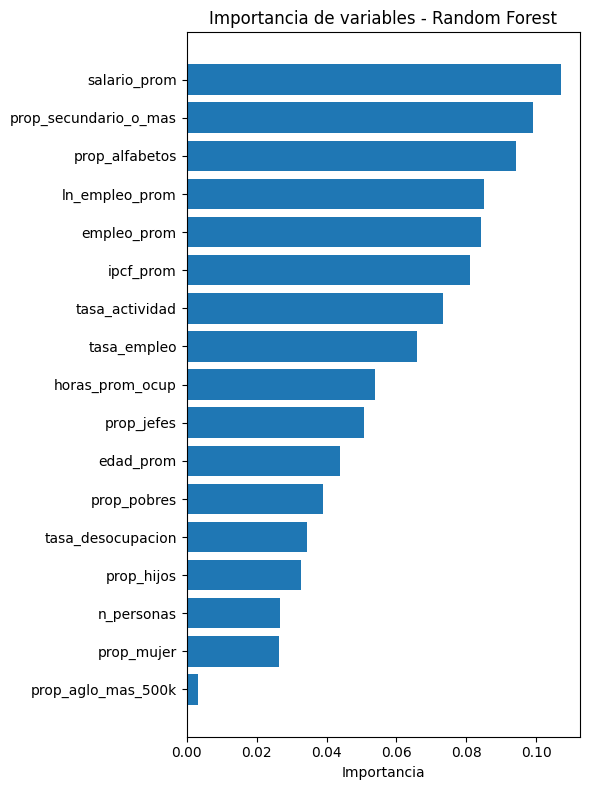

In [ ]:
importances = rf.feature_importances_
features = X_train.columns
imp_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values('importance')

plt.figure(figsize=(6, 8))
plt.barh(imp_df['feature'], imp_df['importance'])
plt.xlabel('Importancia')
plt.title('Importancia de variables - Random Forest')
plt.tight_layout()
plt.show()
